In [1]:
import numpy as np
import pandas as pd

from pathlib import Path

from itertools import chain

from response_stats.generators import PoissonSpikeGenerator
from response_stats.responses import ResponseConfig, make_response_data, ResponseDetector
from response_stats.responses.response_tests import WilcoxonTest, SurrogateTest

from response_stats.plot_utils import *

import matplotlib.pyplot as plt

data_dir = Path("/media/al/darch/response_stats/datasets/2025-12-18_11-28-18/baseline_1000samples_test.yaml-config_2025-12-18_11-28-18.parquet")

In [2]:
data = pd.read_parquet(data_dir)

In [3]:
np.abs(data["n_trials"])

0      34
1      51
2      56
3      10
4      63
       ..
995    28
996    19
997    31
998    15
999    30
Name: n_trials, Length: 1000, dtype: int8

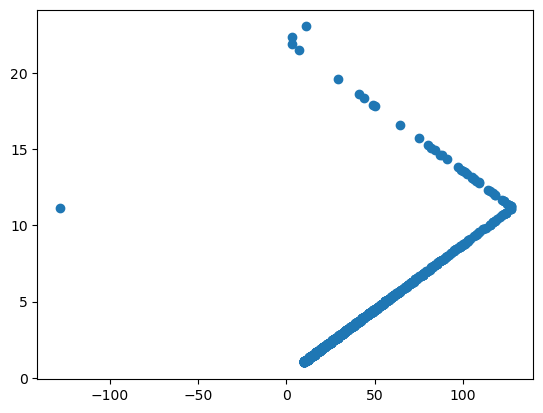

In [4]:
plt.scatter(np.abs(data["n_trials"]), data["fr_response"])

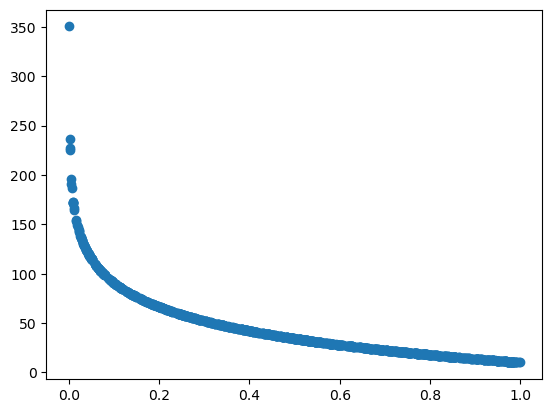

In [16]:

u = rng.uniform(size=1000)
plt.scatter(u, min_trial_num - scale_trial * np.log(u))

Pearson r = 0.106, p = 0.4642759560195243
[0.24014831 0.51754937 0.6663836  0.9771581  0.04884625 0.73009977
 0.80632537 0.69120674 0.3313921  0.15286543 0.54463341 0.93246837
 0.30596919 0.02314546 0.79786772 0.5817671  0.28184996 0.2047476
 0.26345823 0.86015458 0.04044645 0.86838525 0.86598926 0.21598175
 0.67401401 0.23613466 0.51958293 0.83236222 0.22332205 0.66860201
 0.76205275 0.93742871 0.51298664 0.00623352 0.36138226 0.00986445
 0.39273602 0.9573149  0.34873495 0.53038424 0.70935835 0.72803621
 0.66603066 0.8084193  0.0271724  0.34613094 0.53975913 0.2747486
 0.83129234 0.3229646 ]
[ 59  33  24  10 115  21  17  22  48  75  31  12  51 141  17  28  54  65
  56  15 122  14  15  63  23  60  32  16  62  24  19  12  33 187  45 171
  42  11  46  32  22  21  24  17 136  47  31  55  16  49]
[ 2.4039381   1.01136656  1.12628539  1.57974346  4.59860652  9.85491505
  1.62409173  1.04612928  3.74053677  2.6308168   9.04235287  1.46395018
  2.90128359  6.52675371  3.76090106  1.12321449  

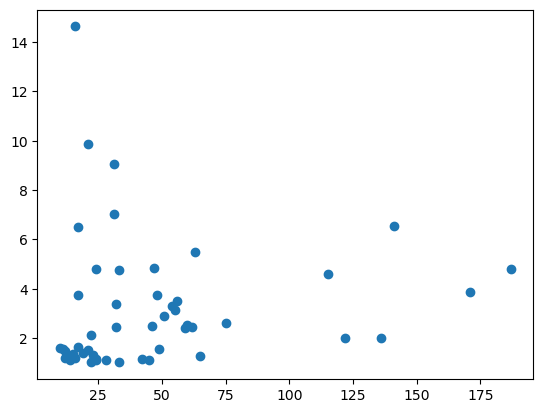

In [20]:
n_samples = 50
threshold = 1
scale = 3 

u = rng.uniform(size=n_samples)
fr_baseline = threshold - scale * np.log(u)

min_trial_num = 10
scale_trial = 35

u = rng.uniform(size=n_samples)
n_trials_list = np.array(min_trial_num - scale_trial * np.log(u), dtype=int)

plt.scatter(n_trials_list, fr_baseline)
r, p = pearsonr(n_trials_list, fr_baseline)
print(f"Pearson r = {r:.3f}, p = {p}")

print(u)
print(n_trials_list)
print(fr_baseline)

In [21]:
p

np.float64(0.4642759560195243)

In [ ]:
rng = np.random.default_rng(seed=73)

n_samples = 10
threshold = 1
scale = 3 



u = rng.uniform(size=n_samples)
fr_baseline = threshold - scale * np.log(u)

print(fr_baseline)

[ 3.12395299  4.57843064  4.94395586  1.04486233  5.54386654 11.32527548
  1.47102439  6.30135395  1.51107373  1.9720494 ]


In [5]:
from scipy.stats import pearsonr

x = np.abs(data["n_trials"])
y =  data["fr_baseline"]

r, p = pearsonr(x, y)
print(f"Pearson r = {r:.3f}, p = {p:.3e}")

Pearson r = 0.777, p = 1.276e-202
